# Demo 1: a cross-power spectrum, from bad to honest

**Say:** "Same data in every plot. The only thing that changes is how honestly we tell it."

Toy 21cm x galaxy cross-spectrum. The numbers are illustrative, not a forecast.
Run the cells in order. Each fix is its own cell.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# --- Toy spectra (illustrative numbers only) ---------------------------------
k = np.logspace(-1.3, 0.5, 14)                      # h/Mpc, roughly 0.05 -> 3

def auto_true(k):                                    # Delta^2_21(k)  [mK^2]
    return 8.0 * (k / 0.1) ** 1.5 / (1 + (k / 0.7) ** 3.2)

def r_true(k):                                       # cross-correlation coefficient, changes sign
    return -0.9 * np.tanh((k - 0.35) / 0.25)

def delta2_cross_true(k):                            # Delta^2_x(k)  [mK]
    return r_true(k) * np.sqrt(auto_true(k) * 0.5)   # 0.5 = toy galaxy Delta^2

def to_P(delta2, k):                                 # P(k) = 2 pi^2 Delta^2 / k^3
    return 2 * np.pi ** 2 * delta2 / k ** 3

# --- "Measurement": truth + errors ------------------------------------------
sig_cv = 0.20 * np.abs(delta2_cross_true(k)) * (0.05 / k) ** 0.5   # larger at low k
sig_th = 0.12 * (k / 0.1) ** 1.2                                    # larger at high k
sigma_d2 = np.sqrt(sig_cv ** 2 + sig_th ** 2)

P_true = to_P(delta2_cross_true(k), k)
sigma  = to_P(sigma_d2, k)
P_meas = to_P(delta2_cross_true(k) + rng.normal(0, sigma_d2), k)    # [mK Mpc^3 h^-3]

kf = np.logspace(-1.3, 0.5, 400)                    # fine grid for the model curve
P_model = to_P(delta2_cross_true(kf), kf)

print(f"{np.sum(P_meas < 0)} of {len(k)} measured points are negative")

6 of 14 measured points are negative


## Step 0: the "default" plot

**Say:** "This is what most of us produce at 11pm. What's wrong with it? Don't answer yet."

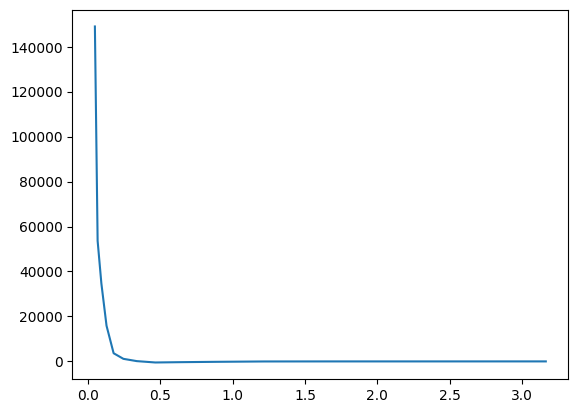

In [2]:
plt.rcdefaults()
fig, ax = plt.subplots()
ax.plot(k, P_meas)
plt.show()

## Step 1: log-log, the standard move

**Say:** "Spectra span decades, so we go log-log. Look at what happens."

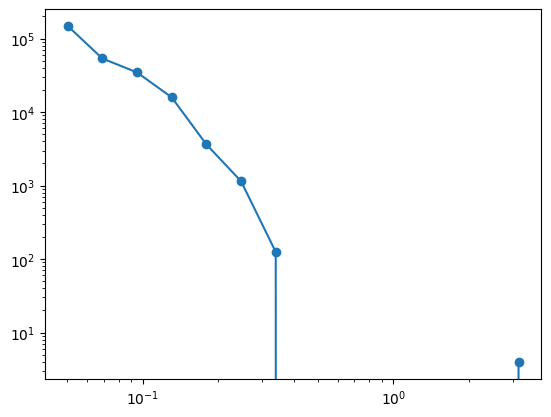

6 negative points are clipped off the bottom of a log axis, and nothing warns you.


In [3]:
fig, ax = plt.subplots()
ax.plot(k, P_meas, "o-")
ax.set_xscale("log")
ax.set_yscale("log")
plt.show()

n_neg = np.sum(P_meas <= 0)
print(f"{n_neg} negative points are clipped off the bottom of a log axis, and nothing warns you.")

## Step 2: show the sign without losing the points

**Say:** "A cross-spectrum is allowed to be negative. Plot |P| and show the sign with the marker:
filled for positive, hollow for negative. State this in the caption."

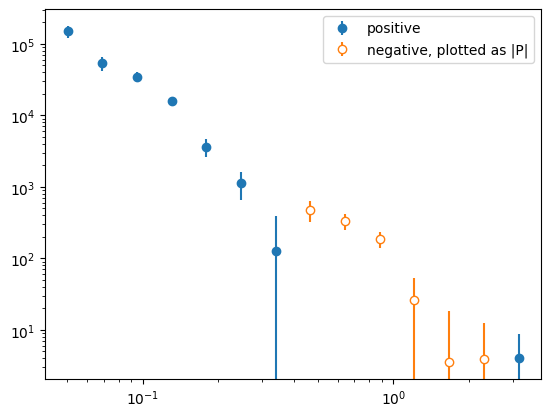

In [4]:
pos = P_meas > 0

fig, ax = plt.subplots()
ax.errorbar(k[pos],  P_meas[pos],  yerr=sigma[pos],  fmt="o", label="positive")
ax.errorbar(k[~pos], -P_meas[~pos], yerr=sigma[~pos], fmt="o", mfc="white", label="negative, plotted as |P|")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
plt.show()

## Step 3: add the model, and a band if the model has uncertainty

**Say:** "Data points get error bars. A continuous curve gets a band. Always say which interval it is."

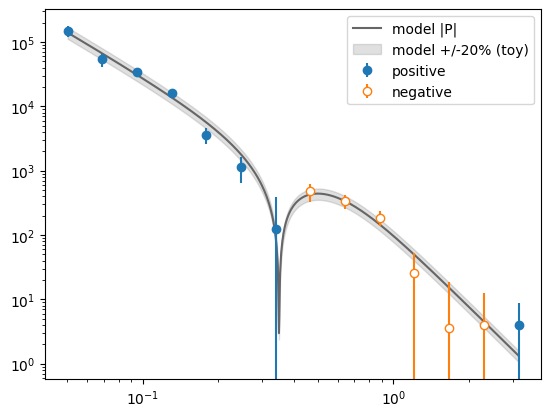

In [5]:
fig, ax = plt.subplots()
ax.plot(kf, np.abs(P_model), color="0.4", label="model |P|")
ax.fill_between(kf, 0.8 * np.abs(P_model), 1.2 * np.abs(P_model),
                color="0.4", alpha=0.2, label="model +/-20% (toy)")
ax.errorbar(k[pos],  P_meas[pos],  yerr=sigma[pos],  fmt="o", label="positive")
ax.errorbar(k[~pos], -P_meas[~pos], yerr=sigma[~pos], fmt="o", mfc="white", label="negative")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
plt.show()

## Step 4: the style: fonts, labels with units, colour-blind-safe colours, column width

**Say:** "Now make it look like it belongs in the paper. Everything here goes in one reusable style."

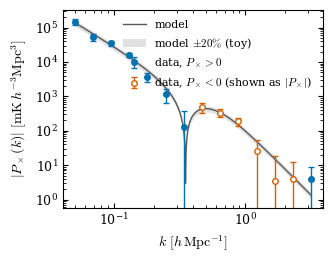

In [6]:
OKABE_BLUE, OKABE_VERMILLION = "#0072B2", "#D55E00"      # colour-blind-safe pair

STYLE = {
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 9,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "figure.figsize": (3.4, 2.7),                        # one MNRAS-style column
}

def cross_spectrum_plot(ax):
    ax.plot(kf, np.abs(P_model), color="0.35", lw=1.0, label="model")
    ax.fill_between(kf, 0.8 * np.abs(P_model), 1.2 * np.abs(P_model),
                    color="0.35", alpha=0.18, lw=0, label=r"model $\pm20\%$ (toy)")
    ax.errorbar(k[pos], P_meas[pos], yerr=sigma[pos], fmt="o", ms=4,
                color=OKABE_BLUE, elinewidth=1, capsize=2, label=r"data, $P_\times>0$")
    ax.errorbar(k[~pos], -P_meas[~pos], yerr=sigma[~pos], fmt="o", ms=4,
                color=OKABE_VERMILLION, mfc="white", elinewidth=1, capsize=2,
                label=r"data, $P_\times<0$ (shown as $|P_\times|$)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
    ax.set_ylabel(r"$|P_\times(k)|\ [\mathrm{mK}\,h^{-3}\mathrm{Mpc}^{3}]$")
    ax.legend(frameon=False, loc="upper right")

with plt.rc_context(STYLE):
    fig, ax = plt.subplots()
    cross_spectrum_plot(ax)
    fig.tight_layout()
    plt.show()

## Step 5: save as a vector PDF and check it at print size

**Say:** "Line art goes out as PDF. Then I open it at the size it will be printed, and read every label."

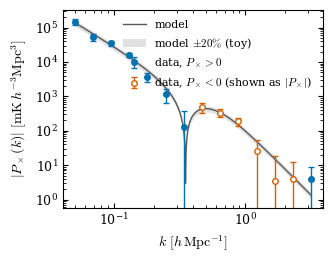

Saved demo1_cross_spectrum.pdf. Open it at 100% and read every label.


In [7]:
with plt.rc_context(STYLE):
    fig, ax = plt.subplots()
    cross_spectrum_plot(ax)
    fig.tight_layout()
    fig.savefig("demo1_cross_spectrum.pdf", bbox_inches="tight")   # vector
    plt.show()

print("Saved demo1_cross_spectrum.pdf. Open it at 100% and read every label.")

## The reveal: before and after, same data

**Say:** "Left: what I started with. Right: what I'd put in a paper."

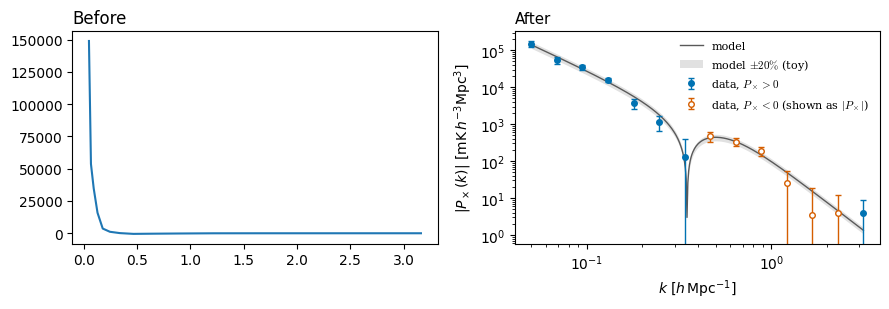

In [8]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(9, 3.2))

with plt.rc_context({"font.size": 10}):
    ax_a.plot(k, P_meas)
    ax_a.set_title("Before", loc="left")

with plt.rc_context(STYLE):
    cross_spectrum_plot(ax_b)
    ax_b.set_title("After", loc="left")

fig.tight_layout()
plt.show()

## If time: the take-home

Copy the `STYLE` dict into a file called `paper.mplstyle` (one `key : value` per line)
and use it with `plt.style.use("paper.mplstyle")`. One style, every figure, one coherent paper.